<a href="https://colab.research.google.com/github/tincr7/Depression_Detective/blob/main/depression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import thư viện cần thiết
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [ ]:
from pathlib import Path

# Đường dẫn tới tệp dữ liệu
data_path = Path('/content/sample_data/depression_data.csv')
# Đọc dữ liệu từ tệp CSV
df = pd.read_csv(data_path)
df.head()

,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413768 entries, 0 to 413767
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Name                          413768 non-null  object 
 1   Age                           413768 non-null  int64  
 2   Marital Status                413768 non-null  object 
 3   Education Level               413768 non-null  object 
 4   Number of Children            413768 non-null  int64  
 5   Smoking Status                413768 non-null  object 
 6   Physical Activity Level       413768 non-null  object 
 7   Employment Status             413768 non-null  object 
 8   Income                        413768 non-null  float64
 9   Alcohol Consumption           413768 non-null  object 
 10  Dietary Habits                413768 non-null  object 
 11  Sleep Patterns                413768 non-null  object 
 12  History of Mental Illness     413768 non-nul

Kiểm tra xem có giá trị rỗng không?



In [ ]:
df.isnull().sum()

,0
Name,0
Age,0
Marital Status,0
Education Level,0
Number of Children,0
Smoking Status,0
Physical Activity Level,0
Employment Status,0
Income,0
Alcohol Consumption,0


Sử dụng biểu đồ histogram để xác định các giá trị ngoại lai

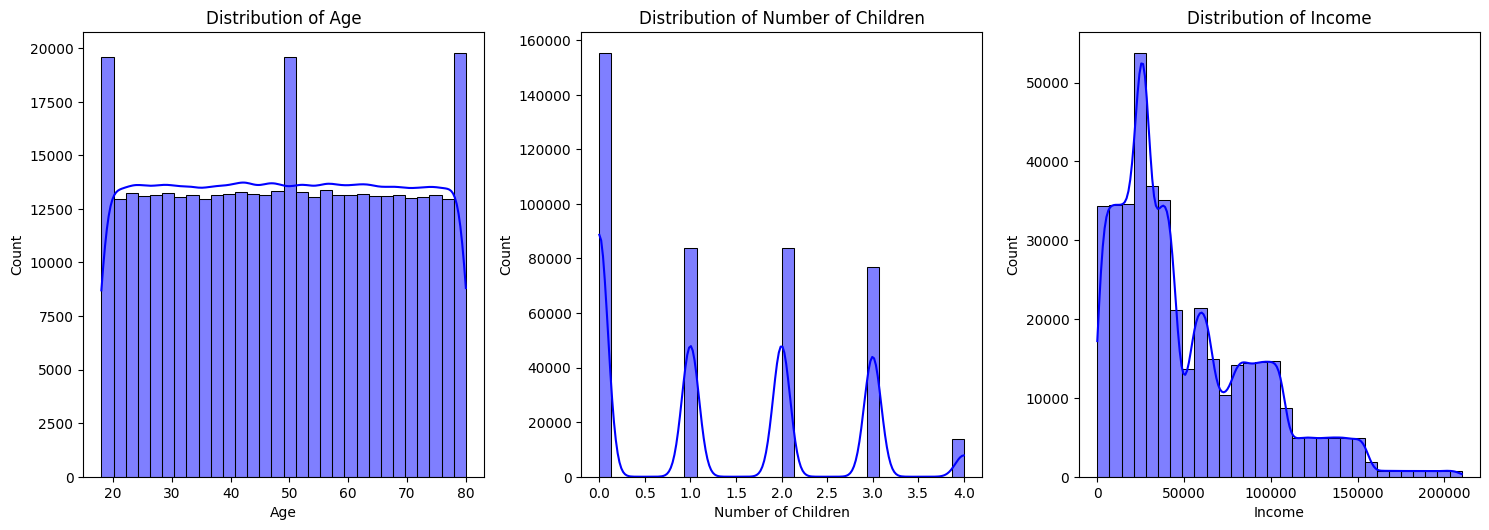

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tạo biểu đồ histogram cho từng cột
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Kích thước biểu đồ
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols) // 3 + 1, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


Áp dụng Box-Cox transformation để loại bỏ giá trị ngoại lai Income

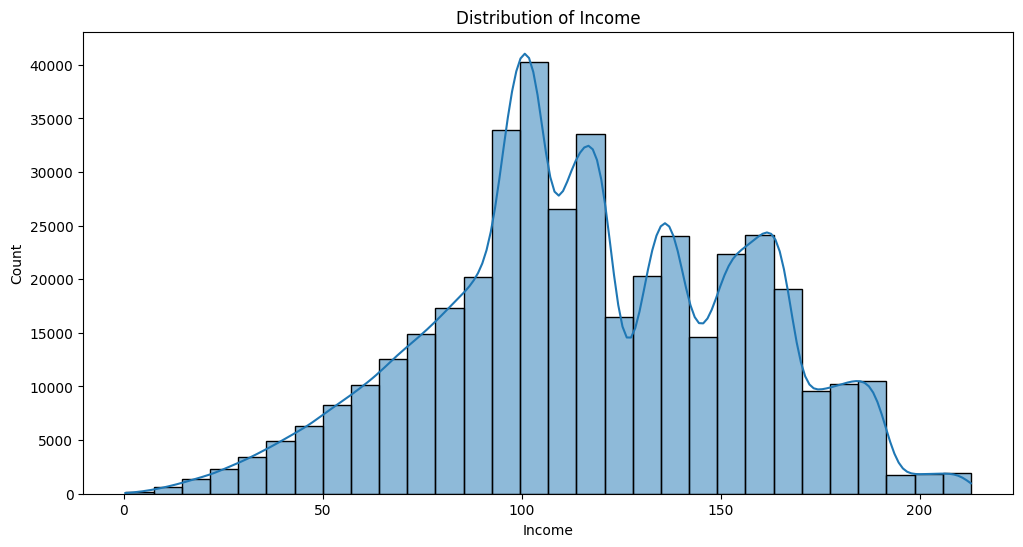

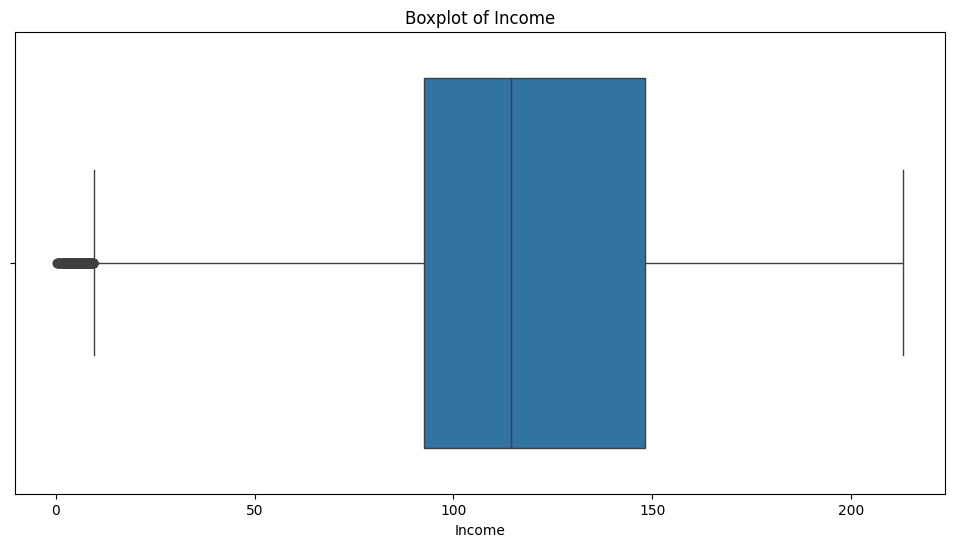

In [ ]:
import numpy as np

from scipy import stats

# Áp dụng Box-Cox transformation
df['Income'], _ = stats.boxcox(df['Income'] + 1)  # Đảm bảo không có giá trị 0

# Kiểm tra lại phân phối
import seaborn as sns
import matplotlib.pyplot as plt

# Vẽ histogram và boxplot cho cột Income
plt.figure(figsize=(12, 6))
# Replacing 'train_df' with 'df'
sns.histplot(df['Income'], kde=True, bins=30)
plt.title('Distribution of Income')
plt.show()

plt.figure(figsize=(12, 6))
# Replacing 'train_df' with 'df'
sns.boxplot(x=df['Income'])
plt.title('Boxplot of Income')
plt.show()

Kiểm tra lại sau khi loại bỏ giá trị ngọai lai

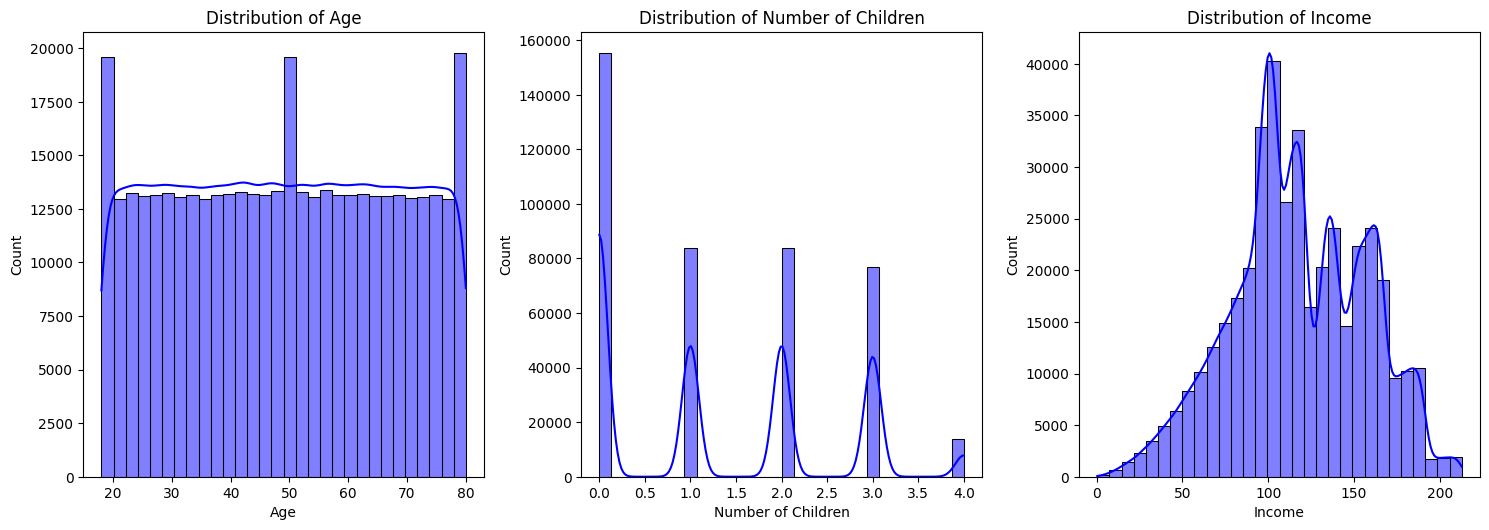

In [ ]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Kích thước biểu đồ
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols) // 3 + 1, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

Liệt kê các giá trị của từng cột

In [ ]:
for column in df.select_dtypes(include=['float64', 'int64']).columns:
    print(f"--- Cột: {column} ---")

    # Các giá trị duy nhất
    unique_values = df[column].unique()
    print(f"Giá trị duy nhất: {unique_values}")

    # Số lượng giá trị
    value_counts = df[column].value_counts()
    print("\nSố lượng giá trị:")
    print(value_counts)

    # Tỷ lệ phân phối
    value_distribution = df[column].value_counts(normalize=True) * 100
    print("\nTỷ lệ phân phối (%):")
    print(value_distribution)

    print("\n")

--- Cột: Age ---
Giá trị duy nhất: [31 55 78 58 18 20 60 50 77 70 59 33 66 38 25 32 52 49 28 56 37 27 69 46
 67 22 26 72 34 53 44 62 51 23 24 35 61 65 63 73 71 76 43 54 40 39 21 19
 64 36 30 45 80 41 48 42 68 75 57 47 79 74 29]

Số lượng giá trị:
Age
42    6740
47    6700
43    6700
24    6695
52    6693
      ... 
18    6470
65    6449
76    6442
35    6429
21    6381
Name: count, Length: 63, dtype: int64

Tỷ lệ phân phối (%):
Age
42    1.628932
47    1.619265
43    1.619265
24    1.618056
52    1.617573
        ...   
18    1.563678
65    1.558603
76    1.556911
35    1.553769
21    1.542169
Name: proportion, Length: 63, dtype: float64


--- Cột: Number of Children ---
Giá trị duy nhất: [2 1 3 0 4]

Số lượng giá trị:
Number of Children
0    155232
2     83961
1     83925
3     76974
4     13676
Name: count, dtype: int64

Tỷ lệ phân phối (%):
Number of Children
0    37.516676
2    20.291806
1    20.283106
3    18.603179
4     3.305234
Name: proportion, dtype: float64


--- Cột: Income

In [ ]:
# Thống kê mô tả cho các tính năng số
df.describe()

,Age,Number of Children,Income
count,413768.000000,413768.000000,413768.000000
mean,49.000713,1.298972,117.082676
std,18.158759,1.237054,38.900152
min,18.000000,0.000000,0.365341
25%,33.000000,0.000000,92.722680
50%,49.000000,1.000000,114.493375
75%,65.000000,2.000000,148.197206
max,80.000000,4.000000,212.916547


Chuẩn bị sẵn sàng dữ liệu cho việc lập mô hình

In [ ]:
from sklearn.preprocessing import LabelEncoder
# Mã hóa dữ liệu phân loại
encoder = LabelEncoder()
categorical_cols = ['History of Mental Illness',
                    'History of Substance Abuse', 'Family History of Depression',
                    'Chronic Medical Conditions']
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

df.drop(columns='Name',inplace = True)

changes = {'Divorced':0,
           'Widowed':1,
           'Single':2,
           'Married':3}
df['Marital Status'] = df['Marital Status'].map(changes)

changes2 = {"Bachelor's Degree":4,
            "High School":3,
            "Associate Degree":2,
            "Master's Degree":1,
            "PhD":0}
df['Education Level'] = df['Education Level'].map(changes2)

changes3 = {'Non-smoker':2,
            'Former':1,
            'Current':0}
df['Smoking Status'] = df['Smoking Status'].map(changes3)

changes4 = {'Sedentary':2,
            'Moderate':1,
            'Active':0}
df['Physical Activity Level'] = df['Physical Activity Level'].map(changes4)

changes5 = {'Employed':1, 'Unemployed':0}
df['Employment Status'] = df['Employment Status'].map(changes5)

changes6 = {'Moderate':2,
            'Low':1,
            'High':0}
df['Alcohol Consumption'] = df['Alcohol Consumption'].map(changes6)

changes7 = {'Unhealthy':2,
            'Moderate':1,
            'Healthy':0}
df['Dietary Habits'] = df['Dietary Habits'].map(changes7)

changes8 = {'Fair':2,
            'Poor':1,
            'Good':0}
df['Sleep Patterns'] = df['Sleep Patterns'].map(changes8)


In [ ]:
df

,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,31,3,4,2,2,0,0,100.589903,2,1,2,1,0,1,1
1,55,3,3,1,2,2,1,119.995154,0,2,2,1,0,0,1
2,78,1,1,1,2,2,1,176.916198,1,2,0,0,0,1,0
3,58,0,1,3,2,1,0,70.648301,2,1,1,0,0,0,0
4,18,2,3,0,2,2,0,66.835218,1,1,2,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413763,68,3,1,0,1,1,1,168.384117,1,0,0,0,0,0,0
413764,26,2,4,0,0,0,1,161.196685,1,0,1,1,1,0,1
413765,57,3,4,0,2,2,1,148.709461,2,1,2,0,0,1,1
413766,71,3,2,2,2,2,0,98.158488,2,1,1,0,1,0,0


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Separate features (X) and target variable (y)
X =df.drop(columns=['History of Mental Illness'])
y =df['History of Mental Illness']

# Khởi tạo mô hình
model = RandomForestClassifier(random_state=42)

# Sử dụng RFE để chọn đặc trưng
rfe = RFE(estimator=model, n_features_to_select=None)  # Chọn tất cả các thuộc tính quan trọng
rfe.fit(X, y)

# Lấy danh sách các đặc trưng được chọn
selected_features = X.columns[rfe.support_]
print("Selected Features:", selected_features)

Selected Features: Index(['Age', 'Education Level', 'Number of Children',
       'Physical Activity Level', 'Income', 'Alcohol Consumption',
       'Dietary Habits'],
      dtype='object')


In [ ]:
# Lọc lại DataFrame để chỉ giữ lại các đặc trưng đã chọn
cleaned_df = df[selected_features.tolist() + ['History of Mental Illness']]

# Kiểm tra lại kích thước của dữ liệu sau khi xóa các đặc trưng không được chọn
print("Kích thước dữ liệu sau khi xóa các đặc trưng không được chọn:")
print(cleaned_df.shape)

Kích thước dữ liệu sau khi xóa các đặc trưng không được chọn:
(413768, 8)


Chuẩn hóa các cột số

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Khởi tạo MinMaxScaler
scaler = MinMaxScaler()

# Lọc các cột số
numerical_columns = cleaned_df.select_dtypes(include=['float64', 'int64']).columns

# Áp dụng MinMaxScaler để chuẩn hóa tất cả các cột số
cleaned_df[numerical_columns] = scaler.fit_transform(cleaned_df[numerical_columns])

print("Data sau khi chuẩn hóa:")
cleaned_df

Data sau khi chuẩn hóa:


<ipython-input-14-fb0511c6b8c7>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df[numerical_columns] = scaler.fit_transform(cleaned_df[numerical_columns])


,Age,Education Level,Number of Children,Physical Activity Level,Income,Alcohol Consumption,Dietary Habits,History of Mental Illness
0,0.209677,1.00,0.50,0.0,0.471531,1.0,0.5,1.0
1,0.596774,0.75,0.25,1.0,0.562828,0.0,1.0,1.0
2,0.967742,0.25,0.25,1.0,0.830627,0.5,1.0,0.0
3,0.645161,0.25,0.75,0.5,0.330664,1.0,0.5,0.0
4,0.000000,0.75,0.00,1.0,0.312724,0.5,0.5,1.0
...,...,...,...,...,...,...,...,...
413763,0.806452,0.25,0.00,0.5,0.790486,0.5,0.0,0.0
413764,0.129032,1.00,0.00,0.0,0.756671,0.5,0.0,1.0
413765,0.629032,1.00,0.00,1.0,0.697922,1.0,0.5,0.0
413766,0.854839,0.50,0.50,1.0,0.460092,1.0,0.5,0.0


Correlation

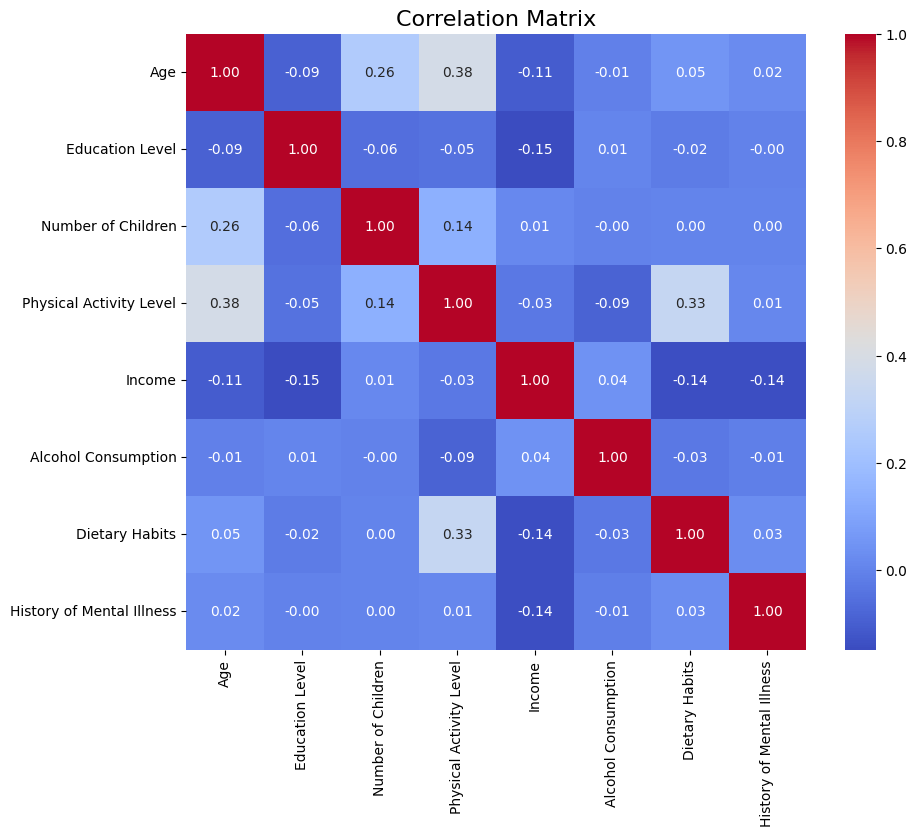

In [ ]:
correlation_matrix = cleaned_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix', fontsize=16)
plt.show()

In [ ]:
class_distribution = cleaned_df['History of Mental Illness'].value_counts()
print(class_distribution)

History of Mental Illness
0.0    287943
1.0    125825
Name: count, dtype: int64


Áp dụng SMOTE để cân bằng dữ liệu

In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split


# Chia dữ liệu thành biến đầu vào (X) và biến mục tiêu (y)
X = cleaned_df.drop('History of Mental Illness', axis=1)
y = cleaned_df['History of Mental Illness']

# Khởi tạo SMOTE
smote = SMOTE(random_state=42)

# Áp dụng SMOTE để tạo dữ liệu cân bằng
X_resampled, y_resampled = smote.fit_resample(X, y)

# Kiểm tra phân phối sau khi áp dụng SMOTE
print("Phân phối lớp sau khi áp dụng SMOTE:")
pd.Series(y_resampled).value_counts()


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Phân phối lớp sau khi áp dụng SMOTE:


,count
History of Mental Illness,
1.0,287943
0.0,287943


# Thực thi thuật toán

In [ ]:
#Split your data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


Thuật toán Decision Tree, Random Forest và LightGBM

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 230195, number of negative: 230513
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.065941 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 598
[LightGBM] [Info] Number of data points in the train set: 460708, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499655 -> initscore=-0.001380
[LightGBM] [Info] Start training from score -0.001380


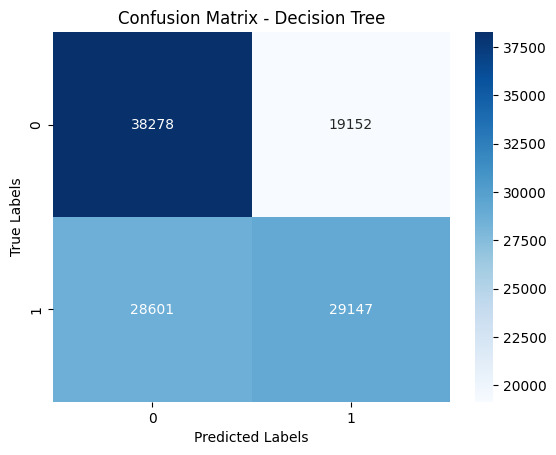

Decision Tree Accuracy: 0.5854
Decision Tree Classification Report:
              precision    recall  f1-score   support

         0.0       0.57      0.67      0.62     57430
         1.0       0.60      0.50      0.55     57748

    accuracy                           0.59    115178
   macro avg       0.59      0.59      0.58    115178
weighted avg       0.59      0.59      0.58    115178



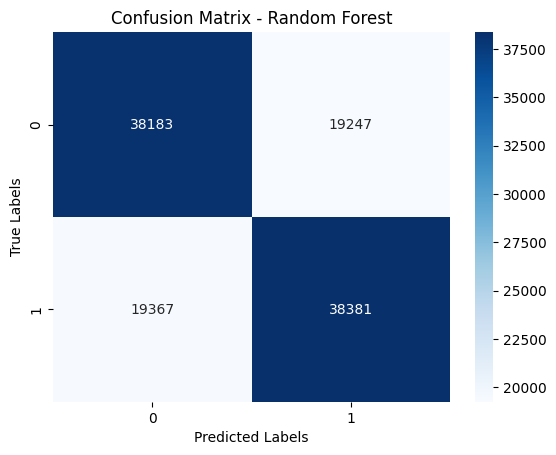

Random Forest Accuracy: 0.6647
Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       0.66      0.66      0.66     57430
         1.0       0.67      0.66      0.67     57748

    accuracy                           0.66    115178
   macro avg       0.66      0.66      0.66    115178
weighted avg       0.66      0.66      0.66    115178



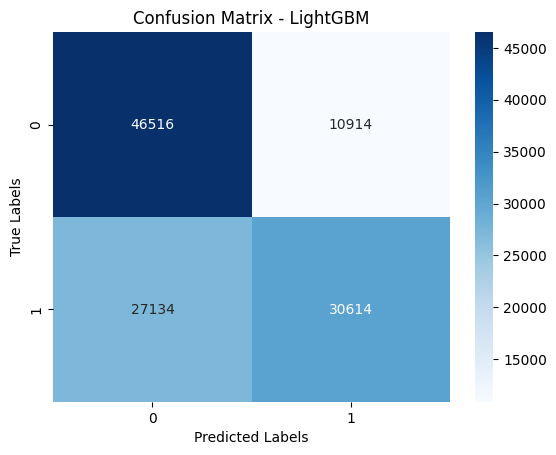

LightGBM Accuracy: 0.6697
LightGBM Classification Report:
              precision    recall  f1-score   support

         0.0       0.63      0.81      0.71     57430
         1.0       0.74      0.53      0.62     57748

    accuracy                           0.67    115178
   macro avg       0.68      0.67      0.66    115178
weighted avg       0.68      0.67      0.66    115178



In [ ]:
# Import thư viện
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Định nghĩa các mô hình
dt_model = DecisionTreeClassifier(random_state=42, max_depth=12)
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
lgb_model = lgb.LGBMClassifier(random_state=42)

# Huấn luyện các mô hình
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
lgb_model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
lightgbm_pred = lgb_model.predict(X_test)

# Đánh giá các mô hình
conf_matrix = confusion_matrix(y_test, dt_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

dt_accuracy = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print("Decision Tree Classification Report:")
print(classification_report(y_test, dt_pred))


conf_matrix = confusion_matrix(y_test, rf_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()
# Tính độ chính xác cho Random Forest
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

conf_matrix = confusion_matrix(y_test, lightgbm_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()
# Tính độ chính xác cho LightGBM
lightgbm_accuracy = accuracy_score(y_test, lightgbm_pred)
print(f"LightGBM Accuracy: {lightgbm_accuracy:.4f}")
print("LightGBM Classification Report:")
print(classification_report(y_test, lightgbm_pred))

Triển khai xác thực chéo k-fold

In [ ]:
from sklearn.model_selection import cross_val_score

# Số lần chia k (k-fold)
k = 5

# K-fold cross-validation cho các mô hình
dt_scores = cross_val_score(dt_model, X_train, y_train, cv=k, scoring='accuracy')
rf_scores = cross_val_score(rf_model, X_train, y_train, cv=k, scoring='accuracy')
lightgbm_scores = cross_val_score(lgb_model, X_train, y_train, cv=k, scoring='accuracy')

# In kết quả k-fold cho mỗi mô hình
print(f"Decision Tree Mean Accuracy: {dt_scores.mean():.4f}")
print(f"Random Forest Mean Accuracy: {rf_scores.mean():.4f}")
print(f"LightGBM Mean Accuracy: {lightgbm_scores.mean():.4f}")


/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_ta

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 184156, number of negative: 184410
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035649 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 593
[LightGBM] [Info] Number of data points in the train set: 368566, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499655 -> initscore=-0.001378
[LightGBM] [Info] Start training from score -0.001378


/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_ta

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 184156, number of negative: 184410
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035647 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 600
[LightGBM] [Info] Number of data points in the train set: 368566, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499655 -> initscore=-0.001378
[LightGBM] [Info] Start training from score -0.001378


/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_ta

...

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 184156, number of negative: 184411
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037469 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 600
[LightGBM] [Info] Number of data points in the train set: 368567, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499654 -> initscore=-0.001384
[LightGBM] [Info] Start training from score -0.001384


/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_ta

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 184156, number of negative: 184411
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.042095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 595
[LightGBM] [Info] Number of data points in the train set: 368567, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499654 -> initscore=-0.001384
[LightGBM] [Info] Start training from score -0.001384


/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Decision Tree Mean Accuracy: 0.5883
Random Forest Mean Accuracy: 0.6561
LightGBM Mean Accuracy: 0.6694


Tuning cho Decision Tree và Random Forest

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd

# Tuning cho Decision Tree
param_distributions_dt = {
    'max_depth': list(range(3, 21)),
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10]
}

random_search_dt = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_distributions_dt,
    n_iter=20,
    scoring='accuracy',
    cv=2,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_dt.fit(X_train, y_train)

# Lấy kết quả tuning cho Decision Tree
results_dt = random_search_dt.cv_results_
combinations_dt = pd.DataFrame({
    'Params': results_dt['params'],
    'Mean Accuracy': results_dt['mean_test_score'],
    'Std Accuracy': results_dt['std_test_score']
}).sort_values(by='Mean Accuracy', ascending=False)

print("Các tổ hợp tham số cho Decision Tree:")
print(combinations_dt)
print("\nBest Parameters for Decision Tree:", random_search_dt.best_params_)
print("Best Accuracy for Decision Tree:", random_search_dt.best_score_)

# Tuning cho Random Forest
param_distributions_rf = {
    'n_estimators': [ 100, 150, 200],
    'max_depth': list(range(3, 21)),
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10],
    'bootstrap': [True, False]
}

random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_distributions_rf,
    n_iter=20,
    scoring='accuracy',
    cv=2,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_rf.fit(X_train, y_train)

# Lấy kết quả tuning cho Random Forest
results_rf = random_search_rf.cv_results_
combinations_rf = pd.DataFrame({
    'Params': results_rf['params'],
    'Mean Accuracy': results_rf['mean_test_score'],
    'Std Accuracy': results_rf['std_test_score']
}).sort_values(by='Mean Accuracy', ascending=False)

print("Các tổ hợp tham số cho Random Forest:")
print(combinations_rf)
print("\nBest Parameters for Random Forest:", random_search_rf.best_params_)
print("Best Accuracy for Random Forest:", random_search_rf.best_score_)


Fitting 2 folds for each of 20 candidates, totalling 40 fits
Các tổ hợp tham số cho Decision Tree:
                                               Params  Mean Accuracy  \
1   {'min_samples_split': 2, 'min_samples_leaf': 1...       0.599582   
8   {'min_samples_split': 5, 'min_samples_leaf': 1...       0.598783   
0   {'min_samples_split': 2, 'min_samples_leaf': 1...       0.597517   
12  {'min_samples_split': 5, 'min_samples_leaf': 1...       0.596630   
6   {'min_samples_split': 10, 'min_samples_leaf': ...       0.596323   
3   {'min_samples_split': 2, 'min_samples_leaf': 1...       0.595132   
16  {'min_samples_split': 5, 'min_samples_leaf': 2...       0.594930   
15  {'min_samples_split': 10, 'min_samples_leaf': ...       0.594513   
10  {'min_samples_split': 2, 'min_samples_leaf': 2...       0.593840   
18  {'min_samples_split': 5, 'min_samples_leaf': 1...       0.591481   
9   {'min_samples_split': 5, 'min_samples_leaf': 5...       0.590654   
2   {'min_samples_split': 2, 'min_sam

Tuning cho LightGBM

In [ ]:
# Import các thư viện cần thiết
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb
import pandas as pd

# Tuning cho LightGBM
param_distributions_lgb = {
    'n_estimators': [100, 200, 300],    # số lượng cây
    'learning_rate': [0.01, 0.1, 0.2],  # Tốc độ học
    'max_depth': list(range(3, 21)),    # Độ sâu của cây
    'num_leaves': [20, 31, 40],         # Số lượng lá tối đa trên mỗi cây
    'min_child_samples': [5, 10, 20],   # Số lượng mẫu tối thiểu cần có ở một nút lá.
    'subsample': [0.6, 0.8, 1.0],       # Tỷ lệ dữ liệu được sử dụng để xây dựng mỗi cây
    'colsample_bytree': [0.6, 0.8, 1.0] # Tỷ lệ các đặc trưng được sử dụng khi xây dựng mỗi cây
}


# RandomizedSearchCV cho LightGBM
random_search_lgb = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_distributions_lgb,
    n_iter=20,
    scoring='accuracy',
    cv=2,  # 2-fold Cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Huấn luyện RandomizedSearchCV cho LightGBM
random_search_lgb.fit(X_train, y_train)

# Lấy kết quả tuning cho LightGBM
results_lgb = random_search_lgb.cv_results_
combinations_lgb = pd.DataFrame({
    'Params': results_lgb['params'],
    'Mean Accuracy': results_lgb['mean_test_score'],
    'Std Accuracy': results_lgb['std_test_score']
}).sort_values(by='Mean Accuracy', ascending=False)

print("Các tổ hợp tham số cho LightGBM:")
print(combinations_lgb)
print("\nBest Parameters for LightGBM:", random_search_lgb.best_params_)
print("Best Accuracy for LightGBM:", random_search_lgb.best_score_)


Fitting 2 folds for each of 20 candidates, totalling 40 fits


/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 230195, number of negative: 230513
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012350 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 598
[LightGBM] [Info] Number of data points in the train set: 460708, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499655 -> initscore=-0.001380
[LightGBM] [Info] Start training from score -0.001380
Các tổ hợp tham số cho LightGBM:
                                               Params  Mean Accuracy  \
5   {'subsample': 0.8, 'num_leaves': 40, 'n_estima...       0.676461   
11  {'subsample': 1.0, 'num_leaves': 40, 'n_estima...       0.676418   
12  {'subsample': 1.0, 'num_leaves': 31, 'n_estima...       0.675773   
17  {'subsample': 1.0, 'num_leaves': 40,

Tính ROC và AUC cho từng mô hình

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 230195, number of negative: 230513
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.043080 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 598
[LightGBM] [Info] Number of data points in the train set: 460708, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499655 -> initscore=-0.001380
[LightGBM] [Info] Start training from score -0.001380


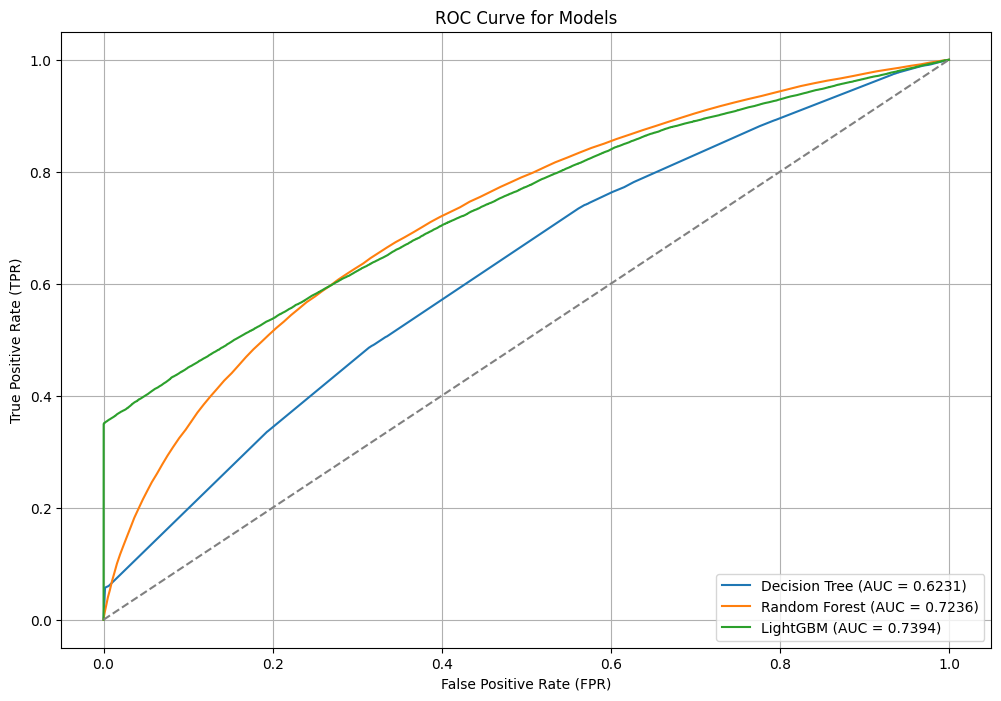

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
lgb_model.fit(X_train, y_train)

# Tính ROC và AUC cho từng mô hình
models = {
    "Decision Tree": (dt_model, dt_pred),
    "Random Forest": (rf_model, rf_pred),
    "LightGBM": (lgb_model, lightgbm_pred)
}

plt.figure(figsize=(12, 8))

for model_name, (model, predictions) in models.items():
    # Xác suất dự đoán cho lớp dương
    y_prob = model.predict_proba(X_test)[:, 1]

    # Tính ROC và AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_value = roc_auc_score(y_test, y_prob)

    # Vẽ đường ROC
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_value:.4f})')

# Vẽ đường chéo (random guessing)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Tùy chỉnh biểu đồ
plt.title('ROC Curve for Models')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid()
plt.show()


Tính mất mát logarit

In [ ]:
from sklearn.metrics import log_loss

# Tính log-loss cho từng mô hình
models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "LightGBM": lgb_model
}

log_loss_results = {}

for model_name, model in models.items():
    # Xác suất dự đoán
    y_prob = model.predict_proba(X_test)

    # Tính log-loss
    loss = log_loss(y_test, y_prob)
    log_loss_results[model_name] = loss
    print(f"{model_name} Log-Loss: {loss:.4f}")


Decision Tree Log-Loss: 0.7270
Random Forest Log-Loss: 0.6611
LightGBM Log-Loss: 0.5719


Phân tính - So sánh hiệu suất của các mô hình

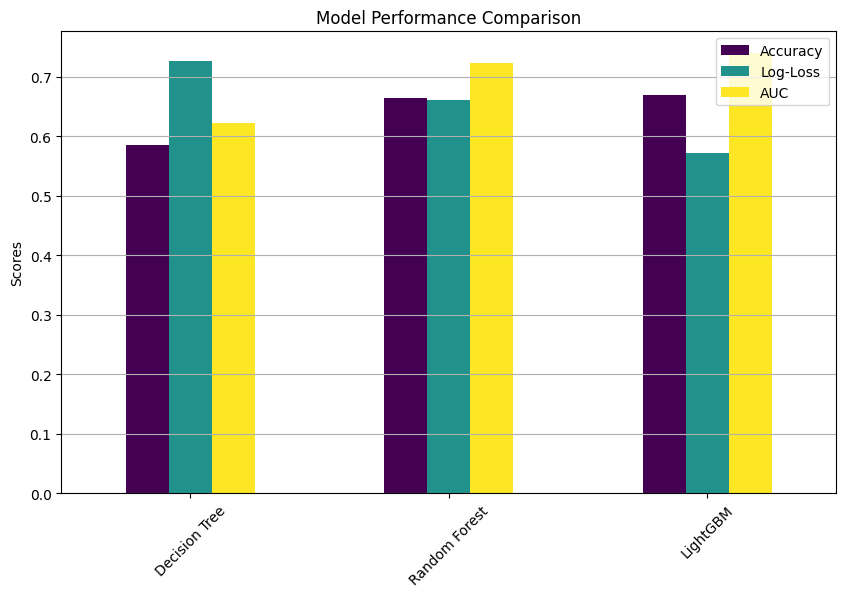

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, log_loss

# Lưu kết quả của các mô hình
results = {}

models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "LightGBM": lgb_model
}

# Tính các chỉ số hiệu suất
for model_name, model in models.items():
    # Accuracy
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    # Log-Loss
    y_prob = model.predict_proba(X_test)
    loss = log_loss(y_test, y_prob)

    # AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    auc_value = roc_auc_score(y_test, y_prob[:, 1])

    # Lưu kết quả
    results[model_name] = {
        "Accuracy": accuracy,
        "Log-Loss": loss,
        "AUC": auc_value,
        "FPR": fpr,
        "TPR": tpr
    }

# Biểu đồ thanh so sánh Accuracy và Log-Loss
comparison = pd.DataFrame(results).T[['Accuracy', 'Log-Loss', 'AUC']]
comparison.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Model Performance Comparison')
plt.ylabel('Scores')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()
